In [9]:
import torch
from NeuralDecoder import MnistNeuralDecoder
import torch
from torch.utils.data import DataLoader , Dataset
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import copy
from GenerateNestedMnistData import CortexMnistDataset

In [10]:
folder='cortex_mnist'

In [11]:
train_dataset = CortexMnistDataset(f'{folder}/train.pt')
val_dataset   = CortexMnistDataset(f'{folder}/val.pt')
test_dataset  = CortexMnistDataset(f'{folder}/test.pt')

device=torch.device('mps')


In [12]:
son,soff,im=test_dataset[5]
print(im.dim())


3


In [13]:

model=MnistNeuralDecoder(grid_size=40)
son=son.unsqueeze(0)
son=son.unsqueeze(2).float()
print(son.shape)
out=model(son)

(11, 11)
torch.Size([1, 26, 1, 40, 40])


In [14]:
print(out.shape)

torch.Size([1, 1, 28, 28])


In [15]:



def train(model, num_epochs: int = 5):
    Epochs = num_epochs
    criterion = torch.nn.MSELoss()
    optimizer = Adam(params=model.parameters(), lr=1e-4)
    best_model = None
    best_loss = +torch.inf
    
    for epoch in range(Epochs):
        train_loss = 0.
        val_loss = 0.        
        model.train()
        train_batches = 0
        for spikes_on, _, images in tqdm(train_dataset, desc=f'Epoch {epoch+1}/{Epochs} Training'):
            optimizer.zero_grad()
            spikes_on = spikes_on.float().to(device)
            images = images.float().to(device)
            spikes_on = spikes_on.unsqueeze(0)
            spikes_on=spikes_on.unsqueeze(2)
            out = model(spikes_on)
            out = out.squeeze(0)
            loss = criterion(out, images)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
        
        # Validation
        model.eval()
        val_batches = 0
        with torch.no_grad():
            for spikes_on, _, images in tqdm(test_dataset, desc=f'Epoch {epoch+1}/{Epochs} Validation'):
                spikes_on = spikes_on.float().to(device)
                images = images.float().to(device)
                spikes_on = spikes_on.unsqueeze(0)
                spikes_on=spikes_on.unsqueeze(2)
                out_val = model(spikes_on)
                out_val = out.squeeze(0)
                loss = criterion(out_val, images)
                
                val_loss += loss.item()
                val_batches += 1
        
        train_loss /= train_batches
        val_loss /= val_batches
        
        if val_loss < best_loss:
            print('New model saved')
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
        
        print(f'Epoch {epoch+1}/{Epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    
    return best_model

In [16]:
model=MnistNeuralDecoder(grid_size=40)
model.to(device)
best_model=train(model)

(11, 11)


Epoch 1/5 Validation:   0%|          | 0/500 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 28, 28])) that is different to the input size (torch.Size([28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1/5 Validation: 100%|██████████| 500/500 [00:10<00:00, 48.18it/s]


New model saved
Epoch 1/5 | Train Loss: 0.0845 | Val Loss: 0.0782


Epoch 2/5 Validation: 100%|██████████| 500/500 [00:10<00:00, 47.71it/s]


New model saved
Epoch 2/5 | Train Loss: 0.0734 | Val Loss: 0.0626


...

New model saved
Epoch 3/5 | Train Loss: 0.0612 | Val Loss: 0.0567


Epoch 4/5 Validation: 100%|██████████| 500/500 [00:12<00:00, 40.81it/s]


New model saved
Epoch 4/5 | Train Loss: 0.0582 | Val Loss: 0.0561


Epoch 5/5 Validation: 100%|██████████| 500/500 [00:12<00:00, 41.31it/s]

Epoch 5/5 | Train Loss: 0.0571 | Val Loss: 0.0562


In [17]:
torch.save(best_model,'NeuralDecoderNested.pth')

In [133]:
model = MnistNeuralDecoder(grid_size=40)
model.load_state_dict(torch.load('NeuralDecoderNested.pth', map_location=device))  # ✅ Don't reassign
model = model.to(device)
model.eval()  # Good practice for inference
import random
idx = random.randint(0, len(test_dataset) - 1)
spikes_on, _, images = test_dataset[idx]
import matplotlib.pyplot as plt
spikes_on = spikes_on.float().to(device)
images = images.float().to(device)
spikes_on = spikes_on.unsqueeze(0)
spikes_on=spikes_on.unsqueeze(2)
out = model(spikes_on)
out = out.squeeze(0)
out = out.squeeze(0)


(11, 11)


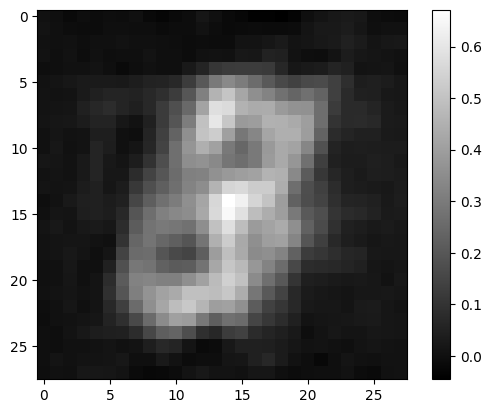

In [134]:
plt.imshow(out.detach().cpu().numpy(),cmap='gray')
plt.colorbar()
plt.show()

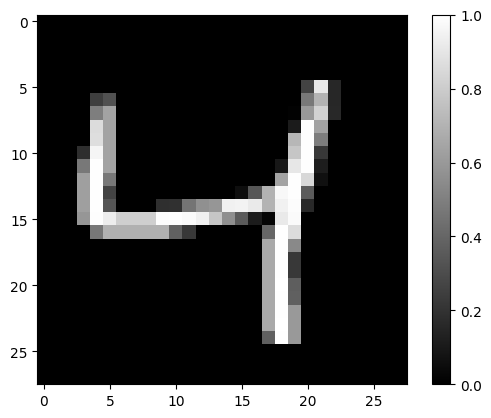

In [135]:
images=images.squeeze(0)
plt.imshow(images.detach().cpu().numpy(),cmap='gray')
plt.colorbar()
plt.show()